# Crate Comparison Analysis

Compare download activity for `runtimelib`, `jupyter-protocol`, `nbformat`, and `zeromq` using crates.io data. The goal is to spot how large `zeromq` usage is relative to `runtimelib`, especially across the most recent complete days.

In [7]:
import json
from urllib.request import Request, urlopen

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

CRATES = ["runtimelib", "jupyter-protocol", "nbformat", "zeromq"]
HEADERS = {"User-Agent": "crate-comparison-analysis"}
TIMEOUT_SECS = 20


def fetch_json(url: str):
    req = Request(url, headers=HEADERS)
    with urlopen(req, timeout=TIMEOUT_SECS) as resp:
        if resp.status != 200:
            raise RuntimeError(f"Request failed for {url}: {resp.status}")
        return json.load(resp)


def fetch_crate_summary(crate: str):
    data = fetch_json(f"https://crates.io/api/v1/crates/{crate}")
    return {
        "crate": crate,
        "total_downloads": data["crate"]["downloads"],
        "versions": len(data["versions"]),
        "newest_version": data["crate"].get("newest_version"),
    }


def fetch_daily_downloads(crate: str):
    data = fetch_json(f"https://crates.io/api/v1/crates/{crate}/downloads")
    df = pd.DataFrame(data["version_downloads"])[["date", "downloads"]].copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.groupby("date", as_index=True)["downloads"].sum().to_frame(name=crate)
    return df

summaries = pd.DataFrame([fetch_crate_summary(crate) for crate in CRATES]).set_index("crate")
daily_totals = pd.concat([fetch_daily_downloads(crate) for crate in CRATES], axis=1, sort=True).fillna(0).sort_index()

# Exclude the latest day so a partial bucket does not distort the tail.
daily_totals = daily_totals[daily_totals.index < daily_totals.index.max()]
last_30 = daily_totals[daily_totals.index >= daily_totals.index.max() - pd.Timedelta(days=30)]
rolling_7 = daily_totals.rolling(7, min_periods=1).mean()

display(summaries)

,total_downloads,versions,newest_version
crate,,,
runtimelib,372750,48,1.5.0
jupyter-protocol,205907,21,1.4.0
nbformat,127895,21,1.2.1
zeromq,1104791,17,0.6.0-pre.1


## Summary

Pull total crate metadata and daily download totals, then compare the last 30 complete days across the four crates.

In [8]:
recent_totals = last_30.sum().sort_values(ascending=False).rename("last_30_complete_days")
recent_share = (recent_totals / recent_totals.sum()).rename("share_of_group")
comparison = pd.concat([summaries, recent_totals, recent_share], axis=1).sort_values(
    "last_30_complete_days", ascending=False
)
comparison["share_of_group"] = comparison["share_of_group"].map(lambda v: f"{v:.1%}")

zeromq_vs_runtimelib = pd.DataFrame(
    {
        "zeromq_last_30": [last_30["zeromq"].sum()],
        "runtimelib_last_30": [last_30["runtimelib"].sum()],
    },
    index=["downloads"],
)
zeromq_vs_runtimelib["difference"] = (
    zeromq_vs_runtimelib["zeromq_last_30"] - zeromq_vs_runtimelib["runtimelib_last_30"]
)
zeromq_vs_runtimelib["ratio"] = (
    zeromq_vs_runtimelib["zeromq_last_30"] / zeromq_vs_runtimelib["runtimelib_last_30"]
)

print("Crate totals and recent activity:\n")
display(comparison)

print("\nzeromq vs runtimelib over the last 30 complete days:\n")
display(zeromq_vs_runtimelib)

ratio = zeromq_vs_runtimelib.loc["downloads", "ratio"]
gap = int(zeromq_vs_runtimelib.loc["downloads", "difference"])
print(f"zeromq is running at {ratio:.2f}x the recent download volume of runtimelib, a gap of {gap:,} downloads over the last 30 complete days.")

Crate totals and recent activity:


,total_downloads,versions,newest_version,last_30_complete_days,share_of_group
zeromq,1104791,17,0.6.0-pre.1,68538.0,50.4%
runtimelib,372750,48,1.5.0,27200.0,20.0%
jupyter-protocol,205907,21,1.4.0,25337.0,18.6%
nbformat,127895,21,1.2.1,14895.0,11.0%



zeromq vs runtimelib over the last 30 complete days:


,zeromq_last_30,runtimelib_last_30,difference,ratio
downloads,68538,27200.0,41338.0,2.519779


zeromq is running at 2.52x the recent download volume of runtimelib, a gap of 41
,338 downloads over the last 30 complete days.


## Trends

Plot daily download totals for all four crates, plus a direct comparison of the gap between `zeromq` and `runtimelib`.

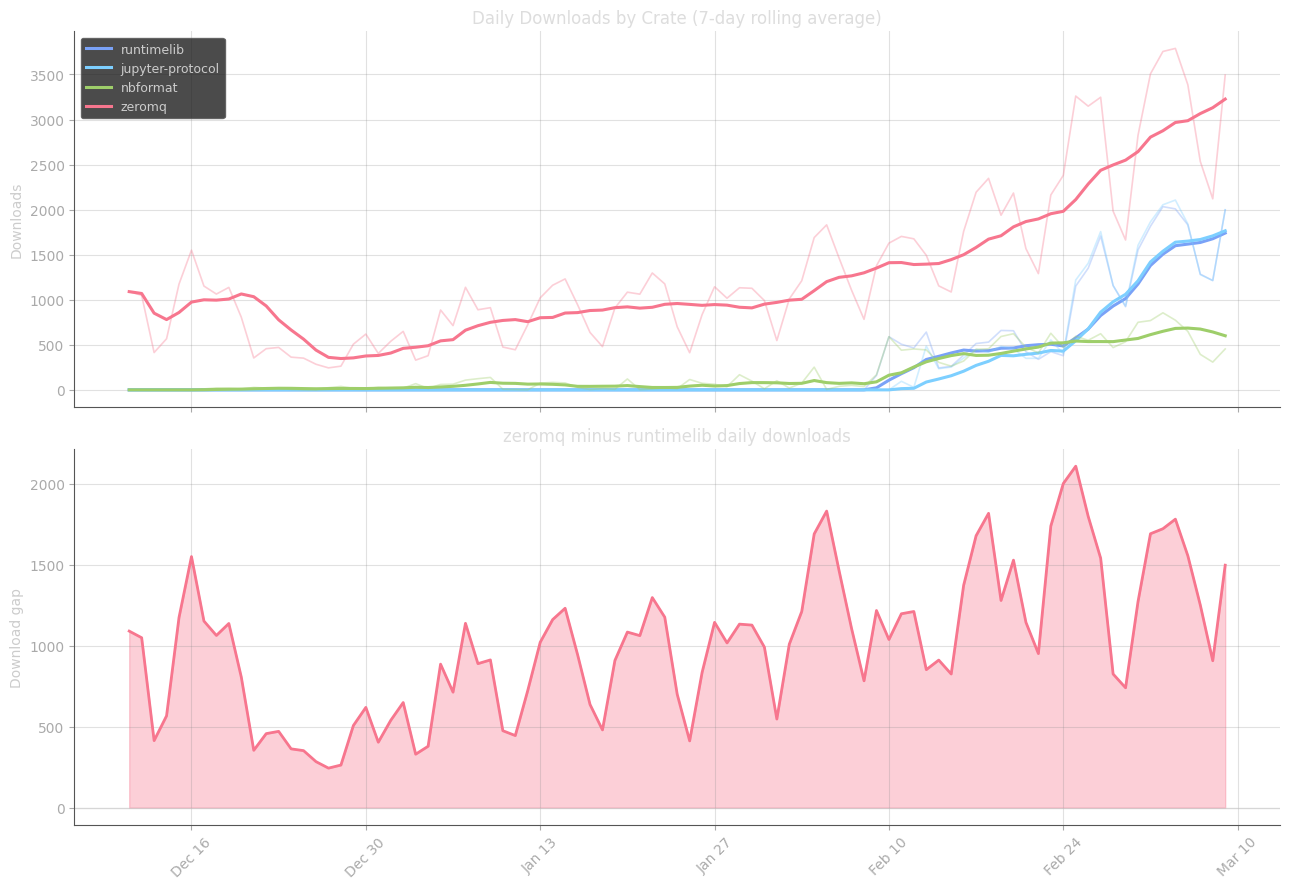

In [9]:
plt.style.use("dark_background")
colors = {
    "runtimelib": "#7aa2f7",
    "jupyter-protocol": "#7dcfff",
    "nbformat": "#9ece6a",
    "zeromq": "#f7768e",
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.patch.set_alpha(0)
for ax in (ax1, ax2):
    ax.set_facecolor("none")
    ax.spines["bottom"].set_color("#555")
    ax.spines["left"].set_color("#555")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors="#aaa")
    ax.yaxis.label.set_color("#ccc")
    ax.title.set_color("#ddd")
    ax.grid(True, alpha=0.25, color="#888")

for crate in CRATES:
    ax1.plot(daily_totals.index, daily_totals[crate], linewidth=1.2, alpha=0.35, color=colors[crate])
    ax1.plot(rolling_7.index, rolling_7[crate], linewidth=2.2, label=crate, color=colors[crate])

ax1.set_title("Daily Downloads by Crate (7-day rolling average)")
ax1.set_ylabel("Downloads")
ax1.legend(loc="upper left", fontsize=9, facecolor="#1e1e1e", edgecolor="#555", labelcolor="#ccc")

comparison_gap = daily_totals["zeromq"] - daily_totals["runtimelib"]
ax2.fill_between(comparison_gap.index, comparison_gap.values, 0, alpha=0.35, color=colors["zeromq"])
ax2.plot(comparison_gap.index, comparison_gap.values, linewidth=2.0, color=colors["zeromq"])
ax2.axhline(0, color="#ccc", linewidth=1, alpha=0.5)
ax2.set_title("zeromq minus runtimelib daily downloads")
ax2.set_ylabel("Download gap")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))

output_path = "/tmp/crate-comparison.png"
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_path, transparent=True, dpi=150)
plt.show()